In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df= pd.read_csv('/content/drive/MyDrive/only.data/Amazon Sale Repor.csv')
df.head()

<ipython-input-1-4d42ca87e6c3>:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('/content/drive/MyDrive/only.data/Amazon Sale Repor.csv')


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [4]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [5]:
df.shape

(128975, 23)

In [10]:
df["Sales Channel "].value_counts()

Sales Channel 
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: int64

#objectives
#1. which city and state has more sales
#2. what kind of product sold more in / in different state and city
#3. which city give more percentage of sales

#4. percentage of cencelation rate
#5. which state have made more cencelation
#6. which product was more cenceled
#7. relationship between b2b and cencelation
#8. relationship between sales chennel and cencelation

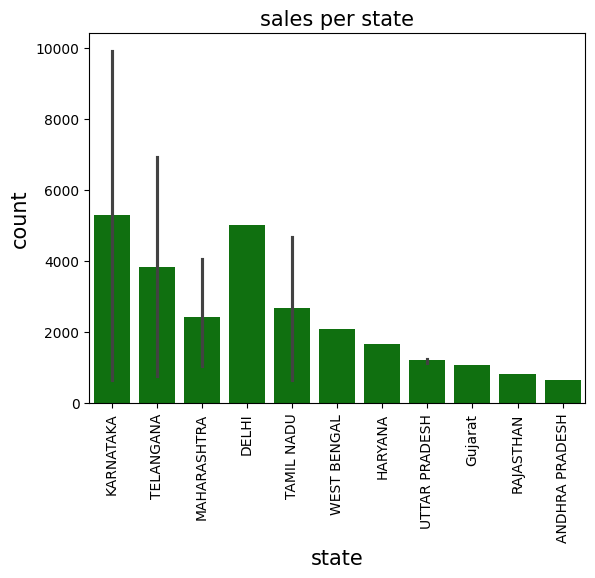

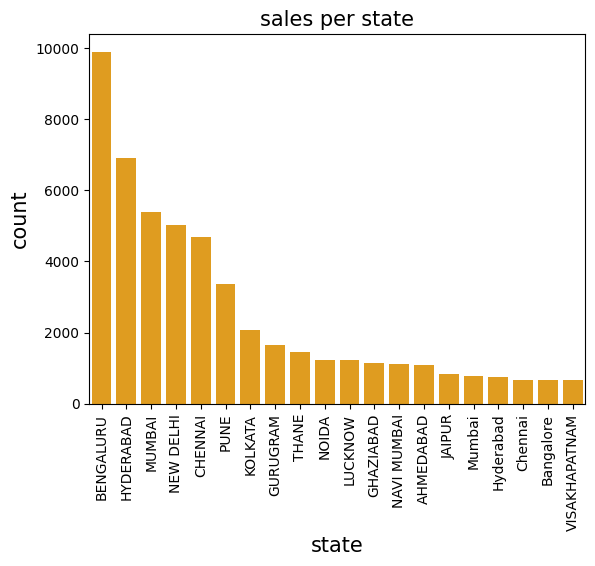

In [49]:
#1. which city and state has more sales
df["ship-city"].value_counts()
df["ship-state"].str.upper()
dff=df[df["Status"] != "Cancelled"]#dont add cenelation one
dff["ship-city"].str.capitalize()
dff["ship-state"].str.capitalize()
df_f=pd.DataFrame(dff[["ship-state","ship-city"]].value_counts().nlargest(20))
sns.barplot(x="ship-state",y="count",data=df_f,color="green")
plt.xticks(rotation=90)
plt.ylabel("count",fontsize=15)
plt.xlabel("state",fontsize=15)
plt.title("sales per state",fontsize=15)
plt.xticks(rotation=90)
plt.show()
sns.barplot(x="ship-city",y="count",data=df_f,color="orange")
plt.xticks(rotation=90)
plt.ylabel("count",fontsize=15)
plt.xlabel("state",fontsize=15)
plt.title("sales per state",fontsize=15)
plt.xticks(rotation=90)
plt.show()

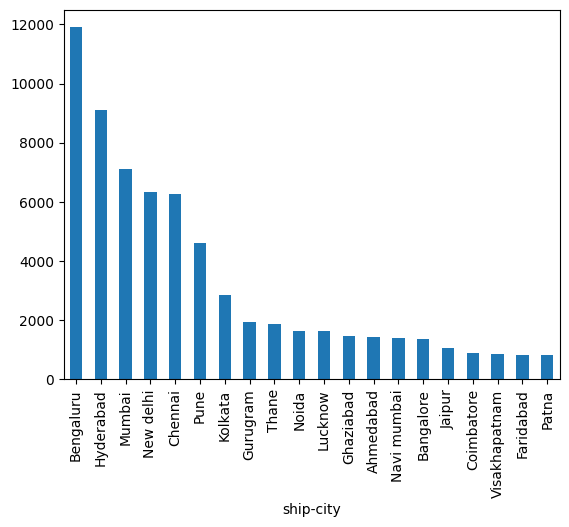

In [68]:
df["ship-city"].value_counts().head(20)
gy=df["ship-city"].str.capitalize().value_counts().head(20).plot(kind="bar")



what kind of product sold more in / in different state and city

<Axes: xlabel='ship-state,ship-city'>

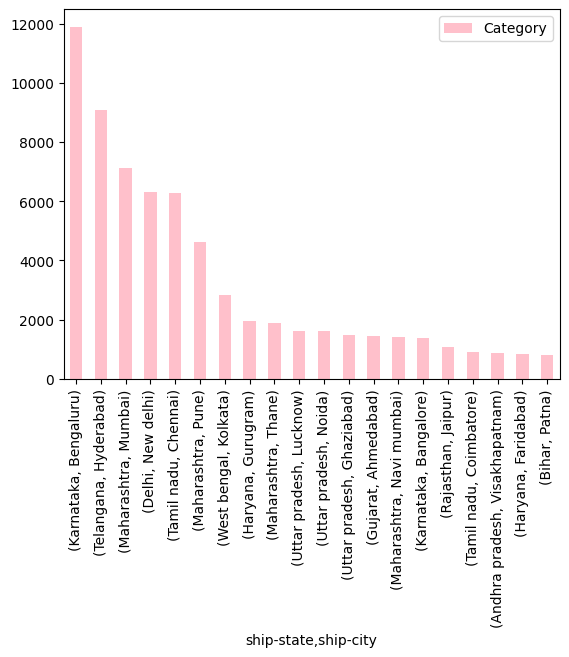

In [70]:
#what kind of product sold more in / in different state and city
df["ship-city"]=df["ship-city"].str.capitalize()
df["ship-state"]=df["ship-state"].str.capitalize()
dd=df.groupby(["ship-state","ship-city"]).agg({"Category":"count"})
dd.nlargest(20,"Category").plot(kind="bar",color="pink")

In [106]:
df.groupby(["ship-state"]).agg({"ship-city":"count"}).nlargest(20,"ship-city")


,,ship-city
ship-state,ship-city,
Karnataka,Bengaluru,11898
Telangana,Hyderabad,9092
Maharashtra,Mumbai,7122
Delhi,New delhi,6311
Tamil nadu,Chennai,6284
Maharashtra,Pune,4617
West bengal,Kolkata,2844
Haryana,Gurugram,1954
Maharashtra,Thane,1877
